In [1]:
!git clone https://github.com/jackie-niu/CS9647-Project.git

Cloning into 'CS9647-Project'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 116 (delta 4), reused 8 (delta 1), pack-reused 100 (from 1)
Receiving objects: 100% (116/116), 64.70 MiB | 20.35 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Filtering content: 100% (8/8), 245.72 MiB | 12.12 MiB/s, done.


In [2]:
%cd CS9647-Project/

/content/CS9647-Project


In [3]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 80.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 9.2 MB/s eta 0:00:00
  Created wheel for tinysegmenter: filename=tinysegmenter-0.3-py3-none-any.whl size=13540 sha256=8cd0184fb4790c1ab2d6d44f5af6d18ed2a036ae4d8aa2179051f41443c01836
  Stored in directory: /root/.cache/pip/wheels/a5/91/9f/00d66475960891a64867914273fcaf78df6cb04d905b104a2a
  Created wheel for feedfinder2: filename=feedfinder2-0.0.4-py3-none-any.whl size=3341 sha256=99b65b8f17ad6dd41671e364b4498bd23952912bfbaf9f92bc3d5b2b8eb971d3
  Stored in 

In [9]:
!python train.py --root_dir /content/CS9647-Project --run_baselines --epochs 10

GPU available: True
[data] Built and cached dataset: /content/drive/MyDrive/pheme_cache/pheme_clean.csv (rows=97410)
[data] label counts: {0: 67952, 1: 29458}
[split] train=68187 val=14611 test=14612
[split] train label counts: {0: 47566, 1: 20621}

[baseline] TF-IDF + Logistic Regression
               precision    recall  f1-score   support

           0     0.9065    0.8664    0.8860     10193
           1     0.7203    0.7938    0.7553      4419

    accuracy                         0.8444     14612
   macro avg     0.8134    0.8301    0.8206     14612
weighted avg     0.8502    0.8444    0.8465     14612

[baseline] LR metrics: {'accuracy': 0.8444429236244183, 'precision': 0.7203285420944558, 'recall': 0.7938447612582032, 'f1': 0.7553019700721283}

[baseline] TF-IDF + Linear SVM
               precision    recall  f1-score   support

           0     0.9131    0.8849    0.8988     10193
           1     0.7522    0.8058    0.7781      4419

    accuracy                         0.8

In [13]:
import pandas as pd

results = pd.DataFrame([
    {"Model": "Logistic Regression (TF-IDF)", "Accuracy": 0.8444, "F1_misinformation": 0.7553},
    {"Model": "Linear SVM (TF-IDF)", "Accuracy": 0.8610, "F1_misinformation": 0.7781},
    {"Model": "DistilBERT", "Accuracy": 0.8943, "F1_misinformation": 0.8247},
])

results.to_csv("/content/drive/MyDrive/pheme_cache/model_results.csv", index=False)

results

,Model,Accuracy,F1_misinformation
0,Logistic Regression (TF-IDF),0.8444,0.7553
1,Linear SVM (TF-IDF),0.8610,0.7781
2,DistilBERT,0.8943,0.8247


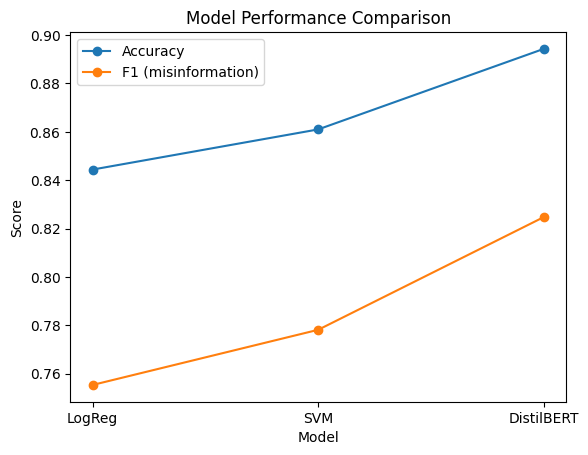

In [14]:
import matplotlib.pyplot as plt

models = ["LogReg", "SVM", "DistilBERT"]
accuracy = [0.8444, 0.8610, 0.8943]
f1 = [0.7553, 0.7781, 0.8247]

plt.figure()

plt.plot(models, accuracy, marker='o', label="Accuracy")
plt.plot(models, f1, marker='o', label="F1 (misinformation)")

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.legend()

plt.savefig("/content/drive/MyDrive/pheme_cache/model_comparison.png")
plt.show()

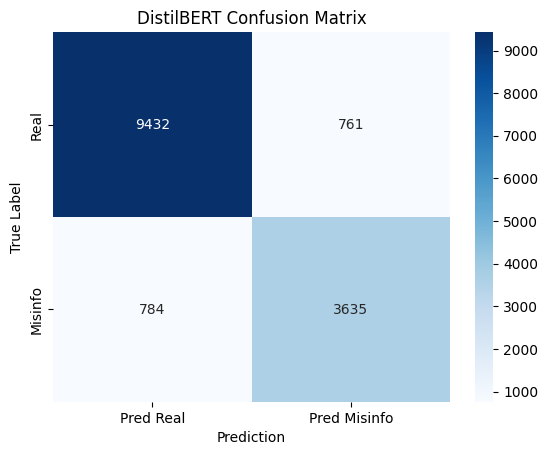

In [18]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

cm = np.array([[9432, 761],
               [784, 3635]])

plt.figure()

sns.heatmap(cm, cmap="Blues", annot=True, fmt="d",
            xticklabels=["Pred Real", "Pred Misinfo"],
            yticklabels=["Real", "Misinfo"])

plt.xlabel("Prediction")
plt.ylabel("True Label")
plt.title("DistilBERT Confusion Matrix")

plt.savefig("/content/drive/MyDrive/pheme_cache/confusion_matrix.png")

plt.show()

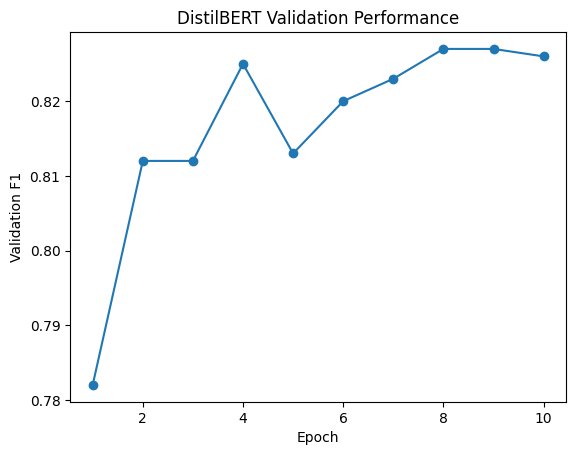

In [19]:
epochs = [1,2,3,4,5,6,7,8,9,10]
val_f1 = [0.782,0.812,0.812,0.825,0.813,0.820,0.823,0.827,0.827,0.826]

plt.figure()

plt.plot(epochs, val_f1, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Validation F1")
plt.title("DistilBERT Validation Performance")

plt.savefig("/content/drive/MyDrive/pheme_cache/training_curve.png")

plt.show()

In [21]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/pheme_cache/pheme_clean.csv")

stats = {
    "total_samples": len(df),
    "misinformation": (df["is_misinformation"] == 1).sum(),
    "non_misinformation": (df["is_misinformation"] == 0).sum(),
}

print(stats)

{'total_samples': 97410, 'misinformation': np.int64(29458), 'non_misinformation': np.int64(67952)}


In [22]:
df["length"] = df["text"].apply(lambda x: len(str(x).split()))

df["length"].describe()

,length
count,97410.000000
mean,14.001263
std,6.541750
min,1.000000
25%,9.000000
50%,15.000000
75%,19.000000
max,34.000000


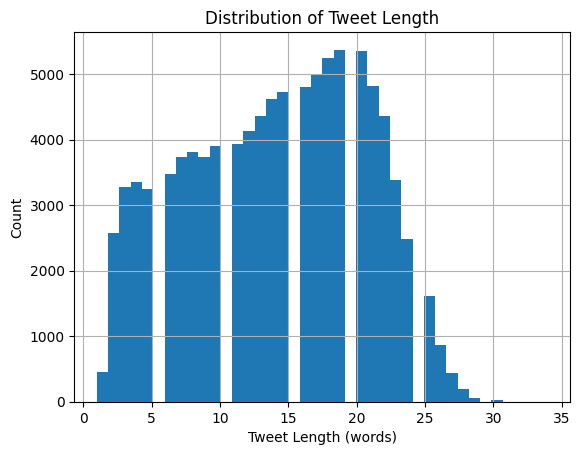

In [23]:
plt.figure()

df["length"].hist(bins=40)

plt.xlabel("Tweet Length (words)")
plt.ylabel("Count")
plt.title("Distribution of Tweet Length")

plt.savefig("/content/drive/MyDrive/pheme_cache/tweet_length_distribution.png")

plt.show()

In [30]:
!zip -r /content/file.zip /content/

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.02.06/ (stored 0%)
  adding: content/.config/logs/2026.02.06/14.30.32.592228.log (deflated 92%)
  adding: content/.config/logs/2026.02.06/14.31.28.771044.log (deflated 86%)
  adding: content/.config/logs/2026.02.06/14.31.44.938153.log (deflated 57%)
  adding: content/.config/logs/2026.02.06/14.31.35.535753.log (deflated 58%)
  adding: content/.config/logs/2026.02.06/14.31.19.332851.log (deflated 58%)
  adding: content/.config/logs/2026.02.06/14.31.45.734270.log (deflated 56%)
  adding: content/.config/default_configs.db (

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cm_lr = np.load("/content/drive/MyDrive/pheme_cache/baseline_outputs/lr_confusion_matrix.npy")

plt.figure()
plt.imshow(cm_lr, interpolation="nearest")
plt.title("Logistic Regression Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/pheme_cache/lr_confusion_matrix.png")
plt.show()

In [ ]:
cm_svm = np.load("/content/drive/MyDrive/pheme_cache/baseline_outputs/svm_confusion_matrix.npy")

plt.figure()
plt.imshow(cm_svm, interpolation="nearest")
plt.title("Linear SVM Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])

for i in range(cm_svm.shape[0]):
    for j in range(cm_svm.shape[1]):
        plt.text(j, i, cm_svm[i, j], ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/pheme_cache/svm_confusion_matrix.png")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/pheme_cache/model_results.csv")

metrics = ["Accuracy", "F1_misinformation"]

for metric in metrics:
    plt.figure()
    plt.bar(df["Model"], df[metric])
    plt.title(f"{metric} by Model")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/pheme_cache/{metric.lower()}_barplot.png")
    plt.show()